PROGRAM 1

In [2]:

#exp-1

import kagglehub
path = kagglehub.dataset_download("fredericobreno/play-tennis")
import pandas as pd

# Read dataset
data = pd.read_csv(f'{path}/play_tennis.csv')

concepts = data.iloc[:, :-1].values
target = data.iloc[:, -1].values

def find_s(concepts, target):
    hypothesis = None

    for i, val in enumerate(target):
        if val.lower() == "yes":
            hypothesis = concepts[i].copy()
            break

    for i, val in enumerate(target):
        if val.lower() == "yes":
            for j in range(len(hypothesis)):
                if hypothesis[j] != concepts[i][j]:
                    hypothesis[j] = '?'

    return hypothesis

print("Most Specific Hypothesis:")
print(find_s(concepts, target))

100%|██████████| 337/337 [00:00<00:00, 1.15MB/s]

Extracting files...
Most Specific Hypothesis:
['?' '?' '?' '?' '?']


PROGRAM 2

In [3]:
#exp-2

import pandas as pd
import numpy as np

data = pd.read_csv(f'{path}/play_tennis.csv')


concepts = np.array(data.iloc[:,0:-1])

target = np.array(data.iloc[:,-1])

def learn(concepts, target):

    specific_h = concepts[0].copy()

    print("Initialization of specific_h and general_h")

    print("specific_h: ",specific_h)

    general_h = [["?" for i in range(len(specific_h))] for i in range(len(specific_h))]

    print("general_h: ",general_h)

    print("concepts: ",concepts)

    for i, h in enumerate(concepts):

        if target[i] == "yes":

            for x in range(len(specific_h)):

                #print("h[x]",h[x])

                if h[x] != specific_h[x]:

                    specific_h[x] = '?'

                    general_h[x][x] = '?'

        if target[i] == "no":

            for x in range(len(specific_h)):

                if h[x] != specific_h[x]:

                    general_h[x][x] = specific_h[x]

                else:

                    general_h[x][x] = '?'

    print("\nSteps of Candidate Elimination Algorithm: ",i+1)

    print("Specific_h: ",i+1)

    print(specific_h,"\n")

    print("general_h :", i+1)

    print(general_h)

    indices = [i for i, val in enumerate(general_h) if val == ['?', '?', '?', '?', '?', '?']]

    print("\nIndices",indices)

    for i in indices:

        general_h.remove(['?', '?', '?', '?', '?', '?'])

    return specific_h, general_h

s_final,g_final = learn(concepts, target)

print("\nFinal Specific_h:", s_final, sep="\n")

print("Final General_h:", g_final, sep="\n")

Initialization of specific_h and general_h
specific_h:  ['D1' 'Sunny' 'Hot' 'High' 'Weak']
general_h:  [['?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?']]
concepts:  [['D1' 'Sunny' 'Hot' 'High' 'Weak']
 ['D2' 'Sunny' 'Hot' 'High' 'Strong']
 ['D3' 'Overcast' 'Hot' 'High' 'Weak']
 ['D4' 'Rain' 'Mild' 'High' 'Weak']
 ['D5' 'Rain' 'Cool' 'Normal' 'Weak']
 ['D6' 'Rain' 'Cool' 'Normal' 'Strong']
 ['D7' 'Overcast' 'Cool' 'Normal' 'Strong']
 ['D8' 'Sunny' 'Mild' 'High' 'Weak']
 ['D9' 'Sunny' 'Cool' 'Normal' 'Weak']
 ['D10' 'Rain' 'Mild' 'Normal' 'Weak']
 ['D11' 'Sunny' 'Mild' 'Normal' 'Strong']
 ['D12' 'Overcast' 'Mild' 'High' 'Strong']
 ['D13' 'Overcast' 'Hot' 'Normal' 'Weak']
 ['D14' 'Rain' 'Mild' 'High' 'Strong']]

Steps of Candidate Elimination Algorithm:  14
Specific_h:  14
['D1' 'Sunny' 'Hot' 'High' 'Weak'] 

general_h : 14
[['?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?'], 

PROGRAM 3

In [4]:
#exp-3

import kagglehub
path = kagglehub.dataset_download("thedevastator/jobs-dataset-from-glassdoor")

import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

data = pd.read_csv(f'{path}/salary_data_cleaned.csv')

X = data.iloc[:, :-1]
Y = data.iloc[:, -1]

encoders = {}

for column in X.columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])
    encoders[column] = le

target = LabelEncoder()
Y = target.fit_transform(Y)

model = DecisionTreeClassifier(criterion="entropy")
model.fit(X, Y)

print("Decision Tree Built Successfully")

sample = [list(X.iloc[0])]
prediction = model.predict(sample)

print("Prediction:", target.inverse_transform(prediction))

100%|██████████| 3.23M/3.23M [00:01<00:00, 2.56MB/s]

Extracting files...


Decision Tree Built Successfully
Prediction: [1]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


PROGRAM 4

In [5]:
#exp-4

import kagglehub
path = kagglehub.dataset_download("shubh0799/churn-modelling")

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

data = pd.read_csv(f'{path}/Churn_Modelling.csv')

X = data.iloc[:, :-1]
Y = data.iloc[:, -1]

# Encode categorical features
for column in X.columns:
    if X[column].dtype == 'object':
        le = LabelEncoder()
        X[column] = le.fit_transform(X[column])

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=0
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000)

model.fit(X_train, Y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, pred))

100%|██████████| 262k/262k [00:00<00:00, 402kB/s]

Extracting files...


Accuracy: 0.8593333333333333


PROGRAM 5

In [6]:
#exp-5

import kagglehub
path = kagglehub.dataset_download("bulentsiyah/knearest-neighbour-knn-classification")

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

data = pd.read_csv(f'{path}/data.csv')

Y = data.iloc[:, 1]

X = data.iloc[:, 2:-1]

le = LabelEncoder()
Y = le.fit_transform(Y)

# X should now only contain numerical features, so no need for a separate encoding loop for X.

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=1
)

model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train, Y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, pred))

100%|██████████| 48.6k/48.6k [00:00<00:00, 1.08MB/s]

Extracting files...
Accuracy: 0.9239766081871345


PROGRAM 6

In [7]:
#exp-6

import kagglehub
path = kagglehub.dataset_download("harshilpatel355/autoirrigationdata")
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

data = pd.read_csv(f'{path}/data.csv')

X = data.iloc[:, :-1]
Y = data.iloc[:, -1]

# Encode categorical features in X
for column in X.columns:
    if X[column].dtype == 'object':
        le = LabelEncoder()
        X[column] = le.fit_transform(X[column])

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=0
)

model = GaussianNB()

model.fit(X_train, Y_train)

pred = model.predict(X_test)

print("Confusion Matrix")

print(confusion_matrix(Y_test, pred))

print("Accuracy")

print(accuracy_score(Y_test, pred))

100%|██████████| 2.75k/2.75k [00:00<00:00, 10.1MB/s]

Extracting files...
Confusion Matrix
[[16  0]
 [ 0 44]]
Accuracy
1.0


PROGRAM 7

In [8]:
#exp-7

import kagglehub
path = kagglehub.dataset_download("dileep070/heart-disease-prediction-using-logistic-regression")
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

data = pd.read_csv(f'{path}/framingham.csv')

X = data.iloc[:, :-1]
Y = data.iloc[:, -1]

# Impute missing values in X with the mean of each column
X = X.fillna(X.mean())

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=0
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, Y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, pred))

100%|██████████| 58.4k/58.4k [00:00<00:00, 1.03MB/s]

Extracting files...


Accuracy: 0.8498427672955975


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


PROGRAM 8

In [9]:
#exp-8

import kagglehub
path = kagglehub.dataset_download("mirichoi0218/insurance")
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

data = pd.read_csv(f'{path}/insurance.csv')

X = data.iloc[:, :-1]
Y = data.iloc[:, -1]

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['number']).columns

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features as they are
)

# Apply the transformations
X_processed = preprocessor.fit_transform(X)

# Convert the processed X back to a DataFrame (optional, for better inspection if needed)
# To get feature names after one-hot encoding:
# new_categorical_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
# all_features = list(new_categorical_features) + list(numerical_features)
# X = pd.DataFrame(X_processed, columns=all_features)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_processed, Y, test_size=0.3, random_state=0
)

model = LinearRegression()

model.fit(X_train, Y_train)

pred = model.predict(X_test)

print("Mean Squared Error:", mean_squared_error(Y_test, pred))

100%|██████████| 16.0k/16.0k [00:00<00:00, 16.7MB/s]

Extracting files...
Mean Squared Error: 33342497.82695457


PROGRAM 9

In [10]:
#exp-9

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error

data = pd.read_csv(f'{path}/insurance.csv')

X = data.iloc[:, :-1]
Y = data.iloc[:, -1]

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['number']).columns

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features as they are
)

# Apply the transformations
X_processed = preprocessor.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_processed, Y, test_size=0.3, random_state=0
)

# Linear Regression
linear = LinearRegression()
linear.fit(X_train, Y_train)
linear_pred = linear.predict(X_test)

# Polynomial Regression
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()

poly_model.fit(X_train_poly, Y_train)

poly_pred = poly_model.predict(X_test_poly)

print("Linear Regression MSE")
print(mean_squared_error(Y_test, linear_pred))

print("Polynomial Regression MSE")
print(mean_squared_error(Y_test, poly_pred))

Linear Regression MSE
33342497.82695457
Polynomial Regression MSE
20067366.792177908


PROGRAM 10

In [11]:
#exp-10

import kagglehub
path = kagglehub.dataset_download("fares279/customers-transactions")
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

data = pd.read_csv(f'{path}/Customer_Transactions.csv')

# Identify categorical and numerical columns
categorical_features = data.select_dtypes(include=['object']).columns
numerical_features = data.select_dtypes(include=['number']).columns

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features as they are
)

# Apply the transformations to X and convert to a dense array
X = preprocessor.fit_transform(data).toarray()

gmm = GaussianMixture(n_components=3, random_state=0)

gmm.fit(X)

labels = gmm.predict(X)

print("Cluster Labels")

print(labels)

100%|██████████| 224k/224k [00:00<00:00, 376kB/s]

Extracting files...


Cluster Labels
[0 2 1 ... 0 0 2]


PROGRAM 11

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Dataset
data = {
    'Income': [25000, 40000, 60000, 30000, 80000, 50000, 70000, 20000, 90000, 45000],
    'Loan': [10000, 15000, 20000, 12000, 25000, 18000, 22000, 8000, 30000, 16000],
    'CreditScore': ['Low', 'Low', 'High', 'Low', 'High',
                    'High', 'High', 'Low', 'High', 'High']
}

df = pd.DataFrame(data)

# Encode target
le = LabelEncoder()
y = le.fit_transform(df['CreditScore'])

X = df[['Income', 'Loan']]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Credit Score Classification")
print("Accuracy:", accuracy_score(y_test, y_pred) * 100, "%")

# New customer
new_customer = [[55000, 17000]]
prediction = model.predict(new_customer)

print("Predicted Credit Score:",
      le.inverse_transform(prediction)[0])

Credit Score Classification
Accuracy: 50.0 %
Predicted Credit Score: High


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


PROGRAM 12

In [13]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# KNN model
model = KNeighborsClassifier(n_neighbors=5)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("Iris Flower Classification using KNN")
print("Accuracy:", accuracy_score(y_test, y_pred) * 100, "%")

# New flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("Predicted Flower:",
      iris.target_names[prediction[0]])

Iris Flower Classification using KNN
Accuracy: 100.0 %
Predicted Flower: setosa


PROGRAM 13

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Dataset
data = {
    'Age': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Kilometers': [10000, 20000, 30000, 40000, 50000,
                   60000, 70000, 80000, 90000, 100000],
    'Price': [900000, 820000, 750000, 680000, 600000,
              530000, 460000, 400000, 330000, 280000]
}

df = pd.DataFrame(data)

X = df[['Age', 'Kilometers']]
y = df['Price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Car Price Prediction")
print("--------------------")
print("Actual Prices:", list(y_test))
print("Predicted Prices:", list(y_pred))

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# New car prediction
new_car = [[3, 30000]]

print("Predicted Price:",
      model.predict(new_car)[0])

Car Price Prediction
--------------------
Actual Prices: [330000, 820000]
Predicted Prices: [np.float64(331810.3448275863), np.float64(818189.6551724139)]
MSE: 3277348.394768119
R2 Score: 0.9999454002766386
Predicted Price: 748706.8965517242


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


PROGRAM 14

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Dataset
data = {
    'Area': [800, 1000, 1200, 1400, 1600,
             1800, 2000, 2200, 2400, 2600],
    'Bedrooms': [2, 2, 3, 3, 3, 4, 4, 4, 5, 5],
    'Price': [2000000, 2500000, 3000000, 3500000, 4000000,
              4500000, 5000000, 5500000, 6000000, 6500000]
}

df = pd.DataFrame(data)

X = df[['Area', 'Bedrooms']]
y = df['Price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("House Price Prediction")
print("---------------------")
print("Actual Prices:", list(y_test))
print("Predicted Prices:", list(y_pred))

print("R2 Score:", r2_score(y_test, y_pred))

# New house
new_house = [[1500, 3]]

print("Predicted House Price:",
      model.predict(new_house)[0])

House Price Prediction
---------------------
Actual Prices: [6000000, 2500000]
Predicted Prices: [np.float64(6000000.0), np.float64(2499999.9999999995)]
R2 Score: 1.0
Predicted House Price: 3749999.9999999995


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


PROGRAM 15

In [16]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Naive Bayes
model = GaussianNB()

# Train
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Iris Classification using Naive Bayes")
print("--------------------------------------")

print("Accuracy:",
      accuracy_score(y_test, y_pred) * 100, "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# New flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("\nPredicted Flower:",
      iris.target_names[prediction[0]])

Iris Classification using Naive Bayes
--------------------------------------
Accuracy: 100.0 %

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Predicted Flower: setosa


PROGRAM 16

In [17]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=200)
}

print("Classification Algorithm Comparison")
print("------------------------------------")

# Train and evaluate
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(name, ":", accuracy * 100, "%")

Classification Algorithm Comparison
------------------------------------
KNN : 100.0 %
Decision Tree : 100.0 %
Naive Bayes : 100.0 %
Logistic Regression : 100.0 %


PROGRAM 17

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Dataset
data = {
    'RAM': [2, 3, 4, 6, 8, 2, 4, 6, 8, 12],
    'Storage': [32, 64, 64, 128, 256, 32, 128, 256, 512, 512],
    'Battery': [3000, 3500, 4000, 4500, 5000,
                3000, 4500, 5000, 5000, 6000],
    'Price_Range': ['Low', 'Low', 'Medium', 'Medium', 'High',
                    'Low', 'Medium', 'High', 'High', 'High']
}

df = pd.DataFrame(data)

X = df[['RAM', 'Storage', 'Battery']]
y = df['Price_Range']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Mobile Price Prediction")
print("Accuracy:", accuracy_score(y_test, y_pred) * 100, "%")

# New mobile
new_mobile = [[6, 128, 4500]]
prediction = model.predict(new_mobile)

print("Predicted Price Range:", prediction[0])

Mobile Price Prediction
Accuracy: 100.0 %
Predicted Price Range: Medium


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


PROGRAM 18

In [19]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Perceptron model
model = Perceptron(max_iter=1000, random_state=42)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("Perceptron Based IRIS Classification")
print("------------------------------------")

print("Accuracy:",
      accuracy_score(y_test, y_pred) * 100, "%")

# New flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("Predicted Flower:",
      iris.target_names[prediction[0]])

Perceptron Based IRIS Classification
------------------------------------
Accuracy: 63.33333333333333 %
Predicted Flower: setosa


PROGRAM 19

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

# Dataset
data = {
    'Age': [25, 35, 45, 28, 50, 40, 30, 55, 32, 48],
    'Income': [25000, 45000, 70000, 30000, 80000,
               60000, 35000, 90000, 40000, 75000],
    'LoanAmount': [10000, 20000, 30000, 12000, 40000,
                   25000, 15000, 50000, 18000, 35000],
    'Loan_Status': ['No', 'Yes', 'Yes', 'No', 'Yes',
                    'Yes', 'No', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)

# Encode target
encoder = LabelEncoder()
y = encoder.fit_transform(df['Loan_Status'])

X = df[['Age', 'Income', 'LoanAmount']]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Bank Loan Prediction")
print("--------------------")

print("Accuracy:",
      accuracy_score(y_test, y_pred) * 100, "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# New customer
new_customer = [[35, 50000, 20000]]

prediction = model.predict(new_customer)

print("\nLoan Prediction:",
      encoder.inverse_transform(prediction)[0])

Bank Loan Prediction
--------------------
Accuracy: 100.0 %

Confusion Matrix:
[[1 0]
 [0 1]]

Loan Prediction: Yes


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


PROGRAM 20

Future Sales Prediction
-----------------------
Month 11 Predicted Sales: 300.0
Month 12 Predicted Sales: 320.0
Month 13 Predicted Sales: 340.0
Month 14 Predicted Sales: 360.0
Month 15 Predicted Sales: 380.0


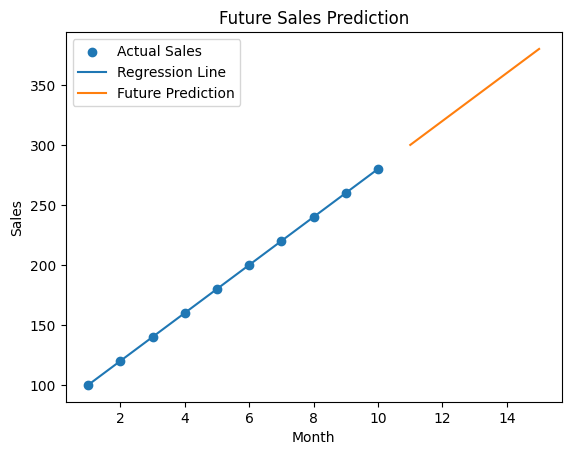

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Sales data
months = np.array([
    1, 2, 3, 4, 5,
    6, 7, 8, 9, 10
]).reshape(-1, 1)

sales = np.array([
    100, 120, 140, 160, 180,
    200, 220, 240, 260, 280
])

# Create model
model = LinearRegression()

# Train model
model.fit(months, sales)

# Predict future sales
future_months = np.array([
    11, 12, 13, 14, 15
]).reshape(-1, 1)

future_sales = model.predict(future_months)

print("Future Sales Prediction")
print("-----------------------")

for month, sale in zip(future_months.flatten(), future_sales):
    print("Month", month, "Predicted Sales:", round(sale, 2))

# Plot
plt.scatter(months, sales, label="Actual Sales")
plt.plot(months, model.predict(months), label="Regression Line")
plt.plot(future_months, future_sales, label="Future Prediction")

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Future Sales Prediction")
plt.legend()
plt.show()